# A minimal plot example

### Load Packages
We need basic packages, intake (for catalogs) and healpix 
Make sure you have the hackathon environment installed. (This may be node specific. Please check with your local host.)

In [7]:
## Standard Stuff
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib.pyplot as plt
import dask.array as da
import numcodecs

## HEALPix Specific
import healpix as hp
import easygems.healpix as egh
import easygems.remap as egr

import intake     # For catalogs
import zarr       # Data Formatting

### Load the catalog

In [11]:
catfn='/home/tmerlis/hackathon/xsh24_scream_main.yaml'
combo_cat = intake.open_catalog(catfn)

# right now, have coarse and native (don't have time-independent bcs)
print(list(combo_cat)) 

['xsh24_coarse', 'xsh24_native', 'xsh21_coarse', 'scream2D_hrly', 'scream_ne120', 'scream_lnd']


In [37]:
zoom_select = 4
ds = combo_cat.xsh24_coarse(zoom=zoom_select).to_dask()
ds = ds.pipe(egh.attach_coords)

# # as of may5, no coarser than level 10 zooms for the native zarr store
# dsn = combo_cat.xsh24_native(zoom=10).to_dask()
# dsn = dsn.pipe(egh.attach_coords)

/home/cs3554/.conda/envs/easy25/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


In [38]:
def worldmap(var, **kwargs):
    projection = ccrs.Robinson(central_longitude=-135.5808361)
    fig, ax = plt.subplots(
        figsize=(8, 4), subplot_kw={"projection": projection}, constrained_layout=True
    )
    ax.set_global()

    hpshow = egh.healpix_show(var, ax=ax, **kwargs)
    cbar = plt.colorbar(hpshow, ax=ax, orientation='vertical', 
                    pad=0.05, shrink=0.8)
    # fails when cartopy tries to download 
    # ax.add_feature(cf.COASTLINE, linewidth=0.8)
    # ax.add_feature(cf.BORDERS, linewidth=0.4)


In [48]:
ds

<xarray.Dataset> Size: 16GB
Dimensions:  (time: 3560, cell: 3072, plev: 31, pfull: 79)
Coordinates:
  * pfull    (pfull) float32 316B 4.514 8.301 12.45 16.74 ... 989.5 994.3 998.3
  * plev     (plev) float32 124B 1.0 2.0 3.0 5.0 7.0 ... 925.0 950.0 975.0 1e+03
  * time     (time) object 28kB 2019-10-20 03:00:00 ... 2021-01-07 00:00:00
    crs      int64 8B 0
  * cell     (cell) int64 25kB 32 96 160 224 288 ... 196384 196448 196512 196576
    lat      (cell) float64 25kB 12.02 32.8 32.8 57.4 12.02 ... nan nan nan nan
    lon      (cell) float64 25kB 33.75 56.25 11.25 ... 360.0 0.000934 0.0003122
Data variables: (12/38)
    clivi    (time, cell) float32 44MB ...
    clt      (time, cell) float32 44MB ...
    clwvi    (time, cell) float32 44MB ...
    hflsd    (time, cell) float32 44MB ...
    hfssd    (time, cell) float32 44MB ...
    hur      (time, plev, cell) float32 1GB ...
    ...       ...
    uas      (time, cell) float32 44MB ...
    va       (time, plev, cell) float32 1GB ...
    vas      (time, cell) float32 44MB ...
    wa       (time, plev, cell) float32 1GB ...
    wap      (time, plev, cell) float32 1GB ...
    zg       (time, plev, cell) float32 1GB ...

In [51]:
ds.where(ds.lat > 0)

<xarray.Dataset> Size: 16GB
Dimensions:  (time: 3560, cell: 3072, plev: 31, pfull: 79)
Coordinates:
  * pfull    (pfull) float32 316B 4.514 8.301 12.45 16.74 ... 989.5 994.3 998.3
  * plev     (plev) float32 124B 1.0 2.0 3.0 5.0 7.0 ... 925.0 950.0 975.0 1e+03
  * time     (time) object 28kB 2019-10-20 03:00:00 ... 2021-01-07 00:00:00
    crs      int64 8B 0
  * cell     (cell) int64 25kB 32 96 160 224 288 ... 196384 196448 196512 196576
    lat      (cell) float64 25kB 12.02 32.8 32.8 57.4 12.02 ... nan nan nan nan
    lon      (cell) float64 25kB 33.75 56.25 11.25 ... 360.0 0.000934 0.0003122
Data variables: (12/38)
    clivi    (time, cell) float32 44MB 0.3044 0.1669 0.3366 ... nan nan nan
    clt      (time, cell) float32 44MB 98.79 91.78 99.06 89.94 ... nan nan nan
    clwvi    (time, cell) float32 44MB 0.1408 0.07768 0.3375 ... nan nan nan
    hflsd    (time, cell) float32 44MB 42.72 59.83 15.47 14.51 ... nan nan nan
    hfssd    (time, cell) float32 44MB -2.047 2.63 -1.463 -1.03 ... nan nan nan
    hur      (time, plev, cell) float32 1GB 0.0578 0.09961 0.03763 ... nan nan
    ...       ...
    uas      (time, cell) float32 44MB 2.608 3.875 0.398 0.08527 ... nan nan nan
    va       (time, plev, cell) float32 1GB 5.899 9.342 5.964 ... nan nan nan
    vas      (time, cell) float32 44MB 0.9701 0.3343 1.5 1.518 ... nan nan nan
    wa       (time, plev, cell) float32 1GB 0.002973 0.002907 ... nan nan
    wap      (time, plev, cell) float32 1GB -0.0005747 -0.00168 ... nan nan
    zg       (time, plev, cell) float32 1GB -7.406e+09 -7.664e+09 ... nan nan

CPU times: user 95.7 ms, sys: 4.62 ms, total: 100 ms
Wall time: 108 ms


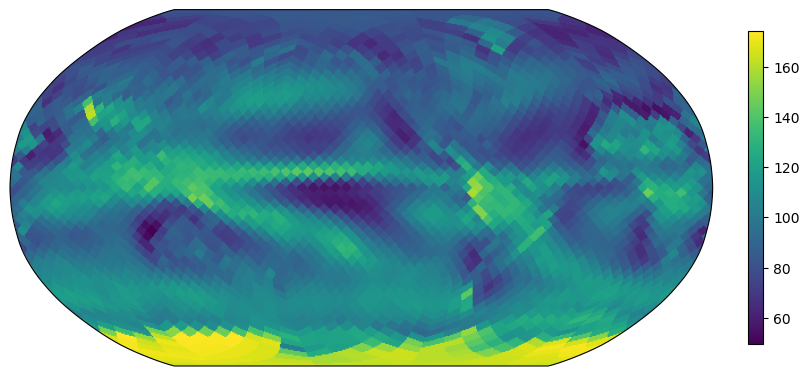

In [45]:
%%time
worldmap(ds.rsut.mean(dim='time'))

CPU times: user 101 ms, sys: 0 ns, total: 101 ms
Wall time: 99.6 ms


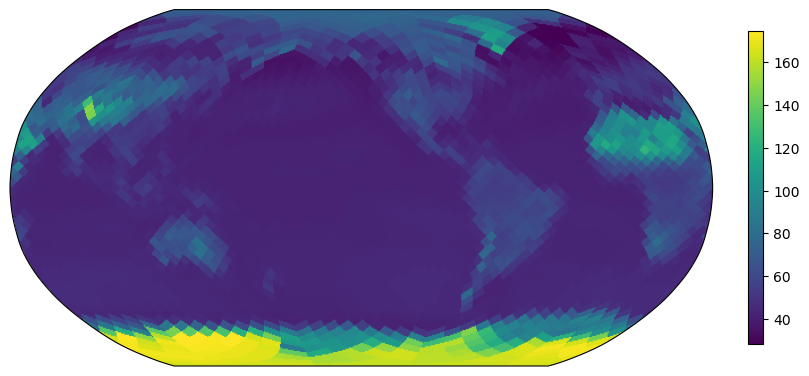

In [46]:
%%time
worldmap(ds.rsutcs.mean(dim='time'))

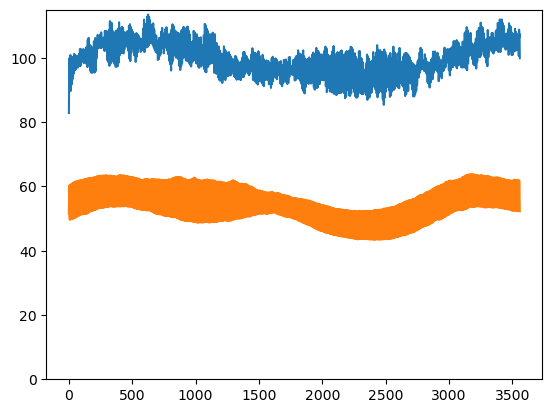

NameError: name 'nh' is not defined

In [47]:
plt.plot(ds.rsut.mean(dim="cell"))
plt.plot(ds.rsutcs.mean(dim="cell"))
plt.ylim(0,115)
plt.show()

plt.plot(nh.rsut.mean(dim="cell"))
plt.plot(sh.rsut.mean(dim="cell"), ls=":", color="C0")
plt.plot(nh.rsutcs.mean(dim="cell"))
plt.plot(sh.rsutcs.mean(dim="cell"), ls=":", color="C1")
plt.ylim(0,115)
plt.show()

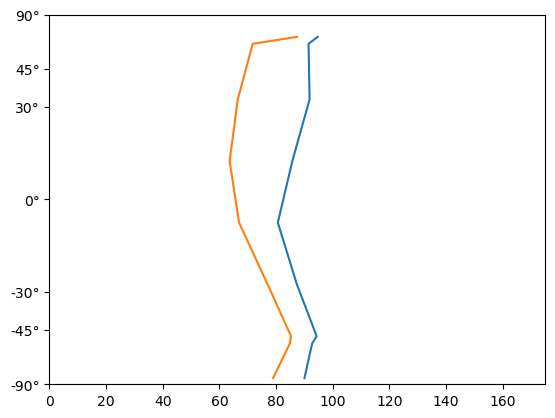

In [43]:
zm = ds.rsut.mean(dim='time').groupby("lat").mean()
zmcs = ds.rsutcs.mean(dim='time').groupby("lat").mean()
plt.plot(zm, np.sin(np.deg2rad(zm.lat)))
plt.plot(zmcs, np.sin(np.deg2rad(zmcs.lat)))
lats = [-90,-45,-30,0,30,45,90]
plt.yticks(np.sin(np.deg2rad(lats)), [str(x)+"°" for x in lats])
plt.ylim(-1,1)
plt.xlim(0,175)
plt.show()